In [1]:
import feyn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy
import warnings
import collections
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_recall_curve, average_precision_score, roc_curve
from IPython.display import display
from auxiliary import *
%matplotlib inline
warnings.filterwarnings('ignore')

This version of feyn and the QLattice is available for academic, personal, and non-commercial use. By using the community version of this software you agree to the terms and conditions which can be found at `https://abzu.ai/privacy`.


# Data Preparation

## 1) Load the data
The data here consists of 8983 genes to be either DEGs or nonDEGs, and 3 omics features, namely copy number viariation, DNA methylation and somatic mutation for the common 677 samples.

In [2]:
data = pd.read_csv('/data/user/shared_projects/moonlight_bc_paper/moonlight_QLattice/Omics_integration/results/multiomics_all_samples.csv')

# Set row names
data = data.set_index('Gene.Symbol')

## 2) Data wrangling
- **Aim:** Aggregate the samples together to reflect an overall situation of each feature type (16 in total).
- **CNV:** We include 2 columns, namely the extreme value and the mean among the samples.
- **Methylation:** 5 columns are included here in terms of the mean beta values within each methylation-related positions.
- **Mutation:** 9 columns here with binary values. We define the value 1 if the gene has driving mutations in certain type/position of mutation in at least 1 sample, no matter how many in that sample.

In [3]:
# Reform the dataset to take the average of cn and me, and the sum of mu types
# Assign the operations 
# extreme_list = ["Cn_", "5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 'Intron', "3'UTR", "3'Flank", 'RNA']
extreme_list = ["Cn_"]
mean_list = ["Cn", "Island", "N_Shore", "S_Shore", "N_Shelf", "S_Shelf"]
sum_list = ["5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 'Intron', "3'UTR", "3'Flank", 'RNA']

# Apply the function for each operation list
agg_sample(data, extreme_list, 'extreme')
agg_sample(data, mean_list, 'mean')
agg_sample(data, sum_list, 'sum')

# Delete data for single samples
data = data[['Cn_', 'Cn', "Island", "N_Shore", "S_Shore", "N_Shelf", "S_Shelf", 
             "5'Flank", "5'UTR", 'Nonsense', 'Splice Site', 'Splice Region', 
             'Intron', "3'UTR", "3'Flank", 'RNA', 'logFC', 'Chromosome']]

# Change column names
data.columns = ['Cn_extreme', 'Cn_mean', "Me_Island", "Me_N_Shore", "Me_S_Shore", "Me_N_Shelf", "Me_S_Shelf", 
             "Mu_5'Flank", "Mu_5'UTR", 'Mu_Nonsense', 'Mu_Splice_Site', 'Mu_Splice_Region', 
             'Mu_Intron', "Mu_3'UTR", "Mu_3'Flank", 'Mu_RNA', 'logFC', 'Chromosome']

In [4]:
# Delete the columns without detected mutations in any genes
data = data.drop(columns = 'Mu_Splice_Site', axis = 1)
data = data.drop(columns = 'Mu_Splice_Region', axis = 1)

In [5]:
# Change mutation columns to binary (if a gene is muated at least in one sample, then we assign 1 to this gene)
data.iloc[:,7:-2] = np.where(data.iloc[:,7:-2] > 0, 1, 0)

## 3) Change target variable

In [6]:
def conditions(df):
    if df['logFC'] == "Non_sign":
        return 0
    elif float(df['logFC']) < 0:
        return 1
    else:
        
        return 2

In [7]:
data['gene_type'] = data.apply(conditions, axis=1)

In [8]:
# Add binary target (0: Non-DE genes / 1: DE genes)
data['gene_type'] = np.where(data['gene_type'] == 0, 0, 1)
data = data.drop(columns = 'logFC', axis = 1)

In [9]:
data

,Cn_extreme,Cn_mean,Me_Island,Me_N_Shore,Me_S_Shore,Me_N_Shelf,Me_S_Shelf,Mu_5'Flank,Mu_5'UTR,Mu_Nonsense,Mu_Intron,Mu_3'UTR,Mu_3'Flank,Mu_RNA,Chromosome,gene_type
Gene.Symbol,,,,,,,,,,,,,,,,
ACAP3,-1.159,-0.144118,0.889598,0.252315,0.876742,0.744749,0.935075,0,0,0,0,0,0,0,chr1,0
AGRN,-1.159,-0.144118,0.613730,0.748747,0.805707,0.712530,0.798269,0,0,0,0,0,0,0,chr1,0
ATAD3A,-1.159,-0.144118,0.579147,0.747231,0.854824,0.000000,0.000000,0,0,0,0,0,0,0,chr1,0
ATAD3B,-1.159,-0.144118,0.375518,0.935386,0.940139,0.650422,0.915811,0,0,0,0,1,0,0,chr1,0
ATAD3C,-1.159,-0.144118,0.771164,0.881127,0.667408,0.828967,0.819369,0,1,1,0,0,0,0,chr1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SHANK3,1.488,-0.166633,0.694185,0.783024,0.692462,0.853706,0.778379,0,0,0,0,0,0,1,chr22,1
TRABD,1.488,-0.166633,0.477889,0.898513,0.436017,0.000000,0.000000,0,0,0,0,0,0,0,chr22,0
TUBGCP6,1.488,-0.166633,0.477608,0.209530,0.930209,0.000000,0.903407,0,0,0,0,0,0,0,chr22,0


# Benchmark

### Random forest (with 5-fold cross validation)

In [10]:
# Delete chromosome feature
if 'Chromosome' in data.columns:
    data = data.drop(columns = 'Chromosome', axis = 1)

# Run RF
best_estimator, y_prob, y_test = random_forest_benchmark(data=data, target='gene_type', n_jobs=50, n_folds=5)

# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_prob)

print(f"Best Estimator: {best_estimator}")
print(f"AUC score: {np.round(auc_score, 2)}")

Best Estimator: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('rf',
                 RandomForestClassifier(max_depth=5, min_samples_split=6))])
AUC score: 0.71


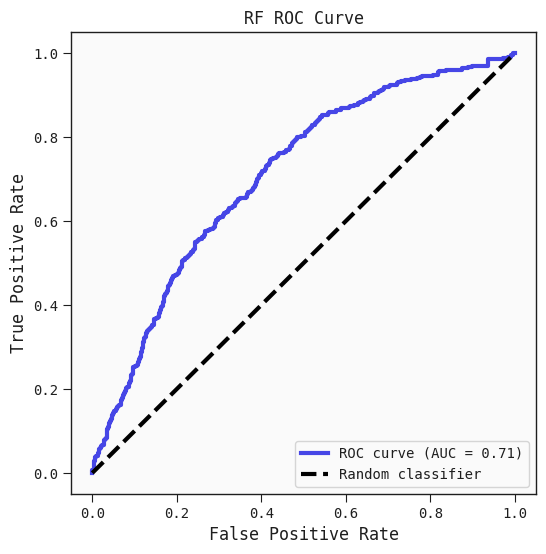

<Figure size 600x600 with 0 Axes>

In [11]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
plt.rcParams["figure.figsize"] = (6,6)
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score)
# roc curve for tpr = fpr 
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('RF ROC Curve', fontsize=12)
plt.legend(loc="lower right")
plt.show()
plt.savefig("../figures/RF_AUC.png", dpi=300, bbox_inches="tight")

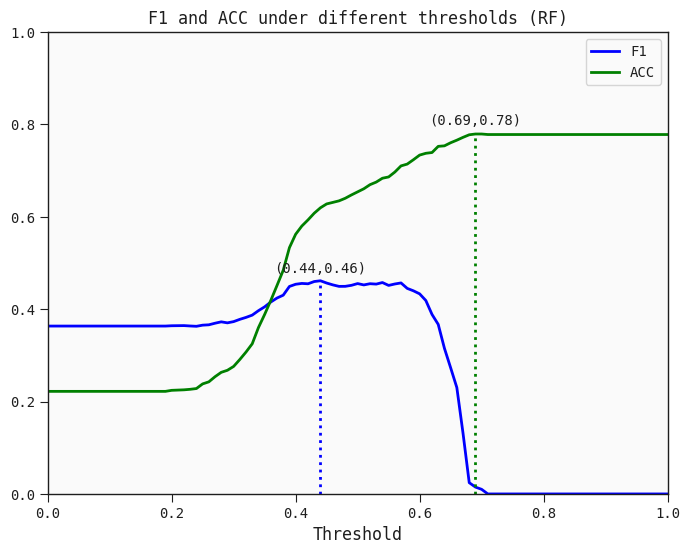

In [12]:
# Calculate the F1 score and ACC with the change of the thresholds
thresholds = np.linspace(0, 1, 101)
f1_scores = []
ACC_scores = []
for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    ACC = accuracy_score(y_test, y_pred)
    f1_scores.append(f1)
    ACC_scores.append(ACC)
    
# Find out the maximal F1 and ACC and the corresponding index of thresholds
max_f1 = np.round(max(f1_scores), 2)
max_f1_T = np.round(thresholds[f1_scores.index(max(f1_scores))], 2)
max_ACC = np.round(max(ACC_scores), 2)
max_ACC_T = np.round(thresholds[ACC_scores.index(max(ACC_scores))], 2)

# Plot the F1 score as a function of the threshold
plt.rcParams["figure.figsize"] = (8,6)
plt.plot(thresholds, f1_scores, color='b', lw=2, label='F1')
plt.plot(thresholds, ACC_scores, color='g', lw=2, label='ACC')
plt.xlabel('Threshold', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('F1 and ACC under different thresholds (RF)', fontsize=12)
plt.vlines(x=max_f1_T, ymin=0, ymax=max_f1, colors='b', ls=':', lw=2)
plt.vlines(x=max_ACC_T, ymin=0, ymax=max_ACC, colors='g', ls=':', lw=2)
plt.text(max_f1_T, max_f1+0.02, '('+str(max_f1_T)+','+str(max_f1)+')', horizontalalignment="center")
plt.text(max_ACC_T, max_ACC+0.02, '('+str(max_ACC_T)+','+str(max_ACC)+')', horizontalalignment="center")
plt.legend(loc='upper right')
plt.savefig("../figures/RF_F1_ACC.png", dpi=300, bbox_inches="tight")

In [13]:
# Set the threshold to the value that produces the largest F1 score for prediction
y_pred = (y_prob >= thresholds[f1_scores.index(max(f1_scores))]).astype(bool)

# Calculate ACC and F1
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {np.round(accuracy, 2)}")
print(f"F1 Score: {np.round(f1, 2)}")

Accuracy: 0.62
F1 Score: 0.46


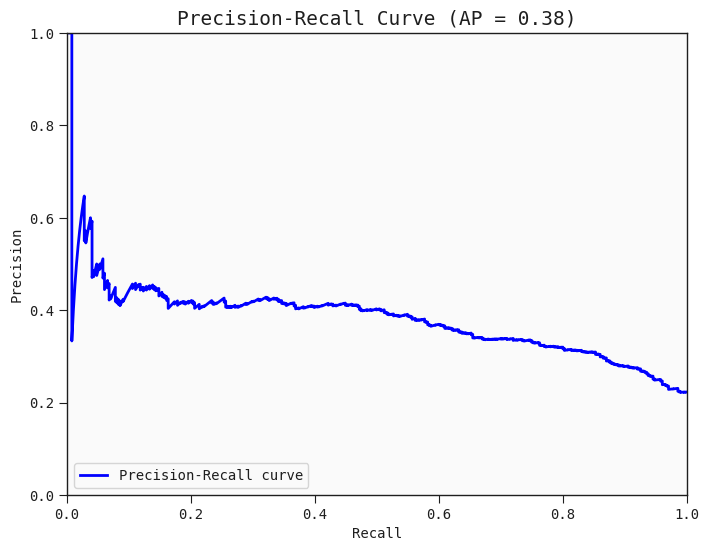

In [14]:
# PR curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

# Plot the precision-recall curve
plt.plot(recall, precision, color='b', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('Precision-Recall Curve (AP = {0:0.2f})'.format(average_precision))
plt.legend(loc="lower left")
plt.show()

In [15]:
# Look at the feature importances of the best classifier
importances = best_estimator.named_steps['rf'].feature_importances_
std = np.std([tree.feature_importances_ for tree in best_estimator.named_steps['rf'].estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(data.iloc[:,:-1].shape[1]):
    print("{}) {} ({:.2f})".format(f + 1, data.iloc[:,:-1].columns[indices[f]], importances[indices[f]]))

Feature ranking:
1) Me_Island (0.44)
2) Me_S_Shore (0.16)
3) Me_N_Shore (0.13)
4) Me_N_Shelf (0.10)
5) Me_S_Shelf (0.07)
6) Cn_mean (0.06)
7) Cn_extreme (0.03)
8) Mu_3'UTR (0.01)
9) Mu_Intron (0.00)
10) Mu_Nonsense (0.00)
11) Mu_5'UTR (0.00)
12) Mu_5'Flank (0.00)
13) Mu_3'Flank (0.00)
14) Mu_RNA (0.00)


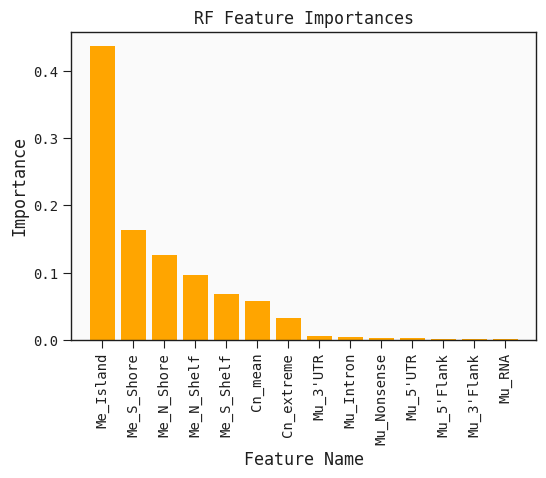

In [16]:
# Plot the feature importances
plt.rcParams["figure.figsize"] = (6,4)
plt.bar(range(data.iloc[:,:-1].shape[1]), importances[indices], color=['orange'], align="center")#, yerr=std[indices], )
plt.title("RF Feature Importances", fontsize=12)
plt.xlabel("Feature Name", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.xticks(range(data.iloc[:,:-1].shape[1]), data.iloc[:,:-1].columns[indices], rotation=90)
plt.xlim([-1, data.iloc[:,:-1].shape[1]])
plt.savefig("../figures/RF_feature_importance.png", dpi=300, bbox_inches="tight")

### LASSO (with 5-fold cross validation)

In [17]:
# Delete chromosome feature
if 'Chromosome' in data.columns:
    data = data.drop(columns = 'Chromosome', axis = 1)

# Run LASSO
best_estimator, y_prob, y_test = lasso_benchmark(data=data, target='gene_type', n_jobs=50, n_folds=5)

# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_prob)

print(f"Best C: {best_estimator.C_[0]}")
print(f"AUC score: {np.round(auc_score, 2)}")

Best C: 0.01
AUC score: 0.62


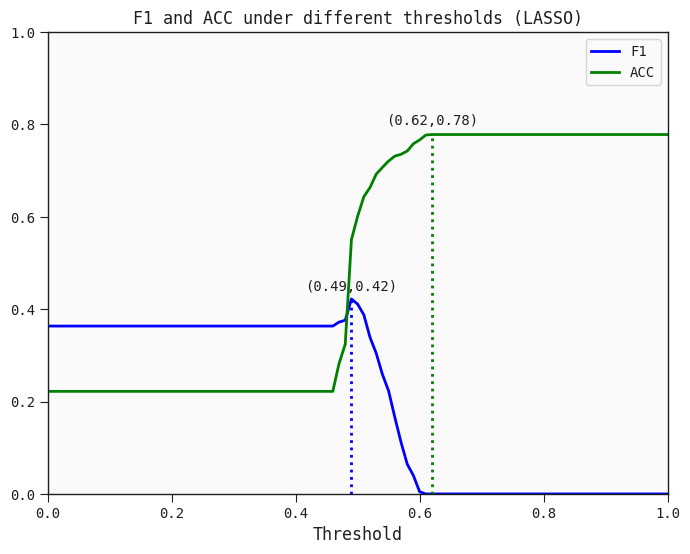

In [18]:
# Calculate the F1 score and ACC with the change of the thresholds
thresholds = np.linspace(0, 1, 101)
f1_scores = []
ACC_scores = []
for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    ACC = accuracy_score(y_test, y_pred)
    f1_scores.append(f1)
    ACC_scores.append(ACC)
    
# Find out the maximal F1 and ACC and the corresponding index of thresholds
max_f1 = np.round(max(f1_scores), 2)
max_f1_T = np.round(thresholds[f1_scores.index(max(f1_scores))], 2)
max_ACC = np.round(max(ACC_scores), 2)
max_ACC_T = np.round(thresholds[ACC_scores.index(max(ACC_scores))], 2)

# Plot the F1 score as a function of the threshold
plt.rcParams["figure.figsize"] = (8,6)
plt.plot(thresholds, f1_scores, color='b', lw=2, label='F1')
plt.plot(thresholds, ACC_scores, color='g', lw=2, label='ACC')
plt.xlabel('Threshold', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('F1 and ACC under different thresholds (LASSO)', fontsize=12)
plt.vlines(x=max_f1_T, ymin=0, ymax=max_f1, colors='b', ls=':', lw=2)
plt.vlines(x=max_ACC_T, ymin=0, ymax=max_ACC, colors='g', ls=':', lw=2)
plt.text(max_f1_T, max_f1+0.02, '('+str(max_f1_T)+','+str(max_f1)+')', horizontalalignment="center")
plt.text(max_ACC_T, max_ACC+0.02, '('+str(max_ACC_T)+','+str(max_ACC)+')', horizontalalignment="center")
plt.legend(loc='upper right')
plt.savefig("../figures/LASSO_F1_ACC.png", dpi=300, bbox_inches="tight")

In [19]:
# Set the threshold to the value that produces the largest F1 score for prediction
y_pred = (y_prob >= thresholds[f1_scores.index(max(f1_scores))]).astype(bool)

# Calculate ACC and F1
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {np.round(accuracy, 2)}")
print(f"F1 Score: {np.round(f1, 2)}")

Accuracy: 0.55
F1 Score: 0.42


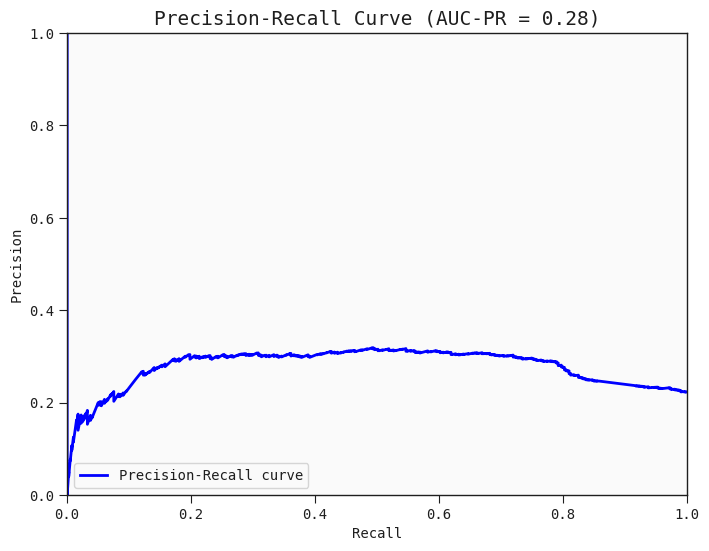

In [20]:
# PR curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

# Plot the precision-recall curve
plt.plot(recall, precision, color='b', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('Precision-Recall Curve (AUC-PR = {0:0.2f})'.format(average_precision))
plt.legend(loc="lower left")
plt.show()

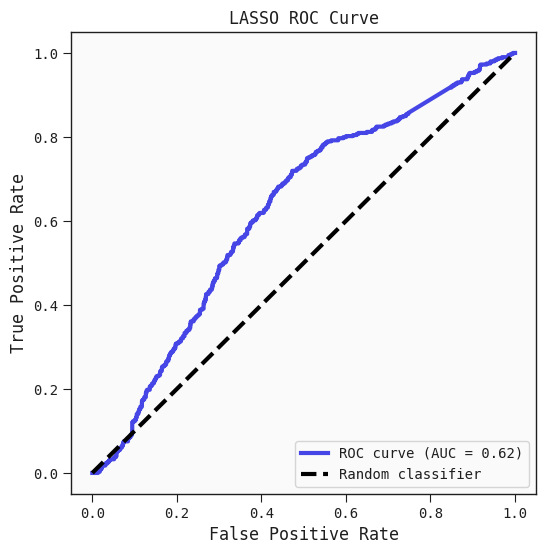

<Figure size 600x600 with 0 Axes>

In [21]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
plt.rcParams["figure.figsize"] = (6,6)
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score)
# roc curve for tpr = fpr 
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('LASSO ROC Curve', fontsize=12)
plt.legend(loc="lower right")
plt.show()
plt.savefig("../figures/LASSO_AUC.png", dpi=300, bbox_inches="tight")

In [22]:
# Get the coefficient values for each feature
coef = best_estimator.coef_[0]

# Get feature names
feature_names = list(data.columns[:-1])
    
# Create a list of tuples containing the feature names and coefficients, 
# sorted by the absolute value of the coefficients
sorted_features = sorted(zip(feature_names, coef), key=lambda x: abs(x[1]), reverse=True)

# Print
for feature, coef in sorted_features:
    print(f"{feature}: {np.round(coef, 3)}")

Me_Island: 0.39
Me_S_Shore: 0.178
Me_S_Shelf: -0.067
Cn_extreme: 0.0
Cn_mean: 0.0
Me_N_Shore: 0.0
Me_N_Shelf: 0.0
Mu_5'Flank: 0.0
Mu_5'UTR: 0.0
Mu_Nonsense: 0.0
Mu_Intron: 0.0
Mu_3'UTR: 0.0
Mu_3'Flank: 0.0
Mu_RNA: 0.0


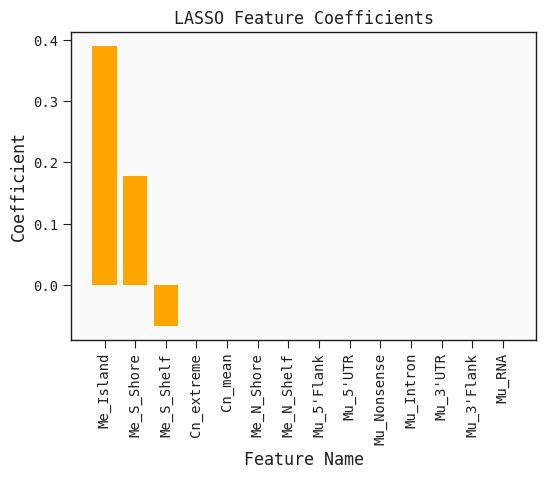

In [23]:
# Extract the sorted feature names and coefficients into separate arrays
sorted_names = [x[0] for x in sorted_features]
sorted_coefs = [x[1] for x in sorted_features]

# Create a bar plot of the sorted feature names and coefficients
plt.rcParams["figure.figsize"] = (6,4)
plt.bar(sorted_names, sorted_coefs, align="center", color=['orange'])#, yerr=se

# Set the x-axis labels to rotate vertically for readability
plt.xticks(rotation=90)

# Add a title and axis labels
plt.title('LASSO Feature Coefficients', fontsize=12)
plt.xlabel('Feature Name', fontsize=12)
plt.ylabel('Coefficient', fontsize=12)

plt.savefig("../figures/LASSO_feature_importance.png", dpi=300, bbox_inches="tight")